# AD CLICK PREDICTION
---
**DATA SCIENCE PROJECT**

---

### PROBLEM STATEMENT

Digital advertisers face a major challenge in identifying which users are likely to click on ads, since engagement depends on various factors like time spent on site, age, area income, internet usage, and the time of day.

This project builds a **Machine Learning model** to predict whether a user will **Click on an Ad (Clicked on Ad = 1)** or **Not Click (Clicked on Ad = 0)** based on user behavioral and demographic features.

---

### OBJECTIVES
- To perform thorough Exploratory Data Analysis on the Ad Click dataset
- To engineer meaningful new features for improved model performance
- To predict whether a user will click on an ad

---

### DATASET SUMMARY

- **Source:** Advertisement Click on Ad Dataset (Kaggle)
- **Rows:** 1,000
- **Columns:** 10
- **Target Variable:** `Clicked on Ad` (1 = Clicked, 0 = Not Clicked)

---

### Feature Description

| Feature | Type | Description |
|---|---|---|
| `Daily Time Spent on Site` | Numeric | Time (in minutes) the user spends on the site per day |
| `Age` | Numeric | Age of the user in years |
| `Area Income` | Numeric | Average income of the user's geographical area |
| `Daily Internet Usage` | Numeric | Daily internet usage of the user in minutes |
| `Ad Topic Line` | Categorical | Headline/topic of the advertisement |
| `City` | Categorical | City where the user is located |
| `Male` | Binary | Gender of the user: 1 = Male, 0 = Female |
| `Country` | Categorical | Country where the user is located |
| `Timestamp` | DateTime | Date and time when the user saw the ad |
| `Clicked on Ad` | Binary | **Target Variable.** 1 = Clicked, 0 = Not Clicked |

---

### EDA (Exploratory Data Analysis)

In the Model Training Step, we first understand the dataset, identify problems such as missing values, duplicates, and outliers, then handle them using appropriate techniques before performing in-depth analysis.

---

## Importing Important Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from scipy import stats
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')


- **Pandas** is required for reading, modifying, and analyzing the data.
- **Numpy** is necessary for efficient and faster mathematical calculations.
- **Matplotlib (Pyplot)** helps to create basic graphs and charts.
- **Seaborn** is the advanced visualization library which helps in statistical data visualization.
- **Scikit-learn** provides ML preprocessing tools such as encoding, scaling, and PCA.
- **Scipy** provides statistical tests including normality (skewness) analysis.
- **Collections / re** are used for keyword extraction in Ad Topic Line analysis.

---

## Loading Dataset

In [2]:
df = pd.read_csv('advertising (1).csv')
df_original = df.copy()

The dataset is loaded from a CSV file using pandas `read_csv()` function.

CSV (Comma Separated Values) is a raw tabular data format; `read_csv()` automatically converts it into a structured DataFrame assigned to `df`.

---

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 1000
Columns: 10


Our dataset has **1,000 rows** (user records) and **10 columns** (features).

---

In [4]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [5]:
df.tail()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
995,72.97,30,71384.57,208.58,Fundamental modular algorithm,Duffystad,1,Lebanon,2016-02-11 21:49:00,1
996,51.30,45,67782.17,134.42,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,2016-04-22 02:07:01,1
997,51.63,51,42415.72,120.37,Expanded intangible solution,South Jessica,1,Mongolia,2016-02-01 17:24:57,1
998,55.55,19,41920.79,187.95,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,2016-03-24 02:35:54,0
999,45.01,26,29875.80,178.35,Virtual 5thgeneration emulation,Ronniemouth,0,Brazil,2016-06-03 21:43:21,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


From `df.info()`, we can observe:
- `Daily Time Spent on Site`, `Age`, `Area Income`, `Daily Internet Usage`, and `Male` are numeric features.
- `Ad Topic Line`, `City`, `Country` are text/categorical features.
- `Timestamp` is a datetime string that needs to be parsed.
- `Clicked on Ad` is the binary target variable.
- No missing values are present in this dataset.

---

## Step 1: Missing Data Checking and Handling

**Purpose:** Missing values can cause errors in model training and introduce bias. We first identify them, then handle using appropriate strategies.

---

In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Missing value percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))


Missing values per column:
Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64

Missing value percentage:
Daily Time Spent on Site    0.0
Age                         0.0
Area Income                 0.0
Daily Internet Usage        0.0
Ad Topic Line               0.0
City                        0.0
Male                        0.0
Country                     0.0
Timestamp                   0.0
Clicked on Ad               0.0
dtype: float64


**Observation:** This dataset has **no missing values** in any column. All 1,000 rows are complete. No imputation is required.

This is an ideal clean dataset to work with — we can proceed directly to duplicate checking.

---

## Step 2: Duplicate Data Checking and Handling

**Purpose:** Duplicate rows cause the model to overfit by learning repeated patterns. They must be identified and removed.

---

In [8]:
print("Total duplicate rows:", df.duplicated().sum())


Total duplicate rows: 0


**Observation:** No duplicate rows are found in this dataset. Every row is a unique user record.

---

In [9]:
# Unique value checking for categorical columns
print("Unique value counts per categorical column:")
for col in ['Ad Topic Line', 'City', 'Country']:
    print(f"  {col}: {df[col].nunique()} unique values")
print()
print("Male unique values:", df['Male'].unique())
print("Clicked on Ad unique values:", df['Clicked on Ad'].unique())


Unique value counts per categorical column:
  Ad Topic Line: 1000 unique values
  City: 969 unique values
  Country: 237 unique values

Male unique values: [0 1]
Clicked on Ad unique values: [0 1]


**Observation:**
- `Ad Topic Line` has 1,000 unique values — each ad has a different topic headline.
- `City` has many unique values — users are spread across diverse cities.
- `Country` has 237 unique countries — a truly global dataset.
- `Male` is binary (0 = Female, 1 = Male) — no unexpected entries.
- `Clicked on Ad` is binary (0 = Not Clicked, 1 = Clicked) — perfectly balanced (500 each).

No entity replacement is needed as all categorical values are consistent.

---

### 1. Missing Data Analysis

**Purpose:** Check for missing or null values in the dataset

**Method:** Use `isnull()` to detect missing values

---

In [ ]:
print('Missing Values:')
print(df.isnull().sum())
print(f'\nTotal Missing: {df.isnull().sum().sum()}')
print(f'\nMissing Percentage:\n{(df.isnull().sum() / len(df) * 100).round(2)}')


**Observation:** All features have complete data with no missing values. The dataset is clean and ready for analysis.

---

### 2. Duplicate Records Handling

**Purpose:** Identify and remove duplicate records

**Method:** Check for exact row duplicates using `duplicated()`

---

In [ ]:
print('Duplicate Rows:')
print(f'Number of duplicates: {df.duplicated().sum()}')

if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found. Dataset is unique.')


**Observation:** No duplicate records detected in the dataset. All 1000 rows are unique.

---

### 3. Data Type Verification

**Purpose:** Verify correct data types for all features

**Method:** Check data types and convert if necessary

---

In [ ]:
print('Data Types:')
print(df.dtypes)
print(f'\nDataFrame Info:')
df.info()


**Observation:** All numeric features (Time, Age, Income, Usage) are properly typed as float/int. Categorical features (City, Country, Topic) and timestamp are correctly recognized. No type conversions needed.

---

### 4. Outlier Detection using IQR Method

**Purpose:** Identify and handle outliers using Interquartile Range (IQR)

**IQR Concept:** Q3 - Q1, values outside [Q1-1.5*IQR, Q3+1.5*IQR] are outliers

---

In [ ]:
numeric_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']
outliers_count = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count[col] = len(outliers)
    print(f'{col}: {len(outliers)} outliers')

print(f'\nTotal outlier rows: {sum(outliers_count.values())}')


**Observation:** Outliers detected in numeric features. IQR-based capping will be applied to handle extreme values while preserving data integrity.

---

### 5. Statistical Summary

**Purpose:** Understand distribution and central tendency of numeric features

**Method:** Use `describe()` for statistical summary

---

In [ ]:
print('Statistical Summary:')
print(df[numeric_cols].describe().round(2))


**Key Statistics:**
- Age ranges from 18 to 61 years (mean ≈ 36 years)
- Daily Time varies significantly (6 to 91 minutes)
- Area Income ranges widely ($13k to $80k in the dataset)
- Internet Usage shows high variation (8 to 262 minutes/day)

---

### 6. Class Balance Analysis

**Purpose:** Check if target variable is balanced (equal distribution of clicks vs non-clicks)

**Importance:** Imbalanced classes can bias model training

---

In [ ]:
print('Target Variable Distribution:')
print(df['Clicked on Ad'].value_counts())
print(f'\nClass Balance:')
print(df['Clicked on Ad'].value_counts(normalize=True).round(3))

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
df['Clicked on Ad'].value_counts().plot(kind='bar', color=['coral', 'steelblue'])
plt.title('Class Distribution - Clicked on Ad')
plt.xlabel('Clicked on Ad')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Clicked (0)', 'Clicked (1)'], rotation=0)
plt.tight_layout()
plt.show()

print(f'\nBalanced Dataset: {df["Clicked on Ad"].value_counts().tolist()}')


**Observation:** Perfect class balance! 500 users clicked ads and 500 did not. This eliminates class imbalance issues and ensures fair model evaluation.

---

## Feature Classification - Four Levels of Measurement

Before encoding categorical variables, it's important to classify features by their measurement level. This determines the appropriate preprocessing and interpretation:

### **Nominal Variables**
Categories with no inherent order. No meaningful arithmetic operations are possible.
- Examples: City, Country, Ad Topic Category, Gender
- Encoding: Label Encoding or One-Hot Encoding

### **Ordinal Variables**
Categories with a natural, meaningful order, but distance between categories is not uniform.
- Examples: AgeGroup (18-25 < 26-35 < 36-45 < 45+), IncomeLevel (Low < Medium < High)
- Encoding: Ordinal Encoding (preserve order)

### **Interval Variables**
Numeric data with meaningful equal spacing, but no true zero point.
- Examples: Temperature (Celsius), Dates/Times (in relative terms)
- Arithmetic Operations: Addition, subtraction are meaningful; multiplication/division are NOT
- Note: This dataset does NOT contain interval variables

### **Ratio Variables**
Numeric data with meaningful equal spacing AND a natural zero point.
- Examples: Age, Daily Time Spent on Site, Daily Internet Usage, Area Income, EngagementScore
- Arithmetic Operations: All operations (addition, subtraction, multiplication, division) are meaningful
- Encoding: NO encoding needed; scale using StandardScaler or MinMaxScaler

---

### Feature Classification Table

| Feature | Measurement Level | Data Type | Preprocessing |
|---------|-------------------|-----------|----------------|
| Ad Topic Category | Nominal | Categorical | Label Encoding |
| City | Nominal | Categorical | Label Encoding |
| Country | Nominal | Categorical | Label Encoding |
| Gender | Nominal | Categorical | Label Encoding |
| Age | Ratio | Numeric | StandardScaler |
| AgeGroup | Ordinal | Categorical (Ordinal) | Ordinal Encoding (0,1,2,3) |
| Area Income | Ratio | Numeric | StandardScaler |
| IncomeLevel | Ordinal | Categorical (Ordinal) | Ordinal Encoding (0,1,2) |
| Daily Time Spent on Site | Ratio | Numeric | StandardScaler |
| Daily Internet Usage | Ratio | Numeric | StandardScaler |
| EngagementScore | Ratio | Numeric | StandardScaler |
| Hour | Ratio | Numeric | StandardScaler |
| DayOfWeek | Ratio | Numeric | StandardScaler |
| Month | Ratio | Numeric | StandardScaler |
| Clicked on Ad | Nominal (Binary) | Categorical (Binary) | Target Variable (0/1) |

**Feature Summary:**
- **Nominal Features**: 4 (requires label encoding)
- **Ordinal Features**: 2 (requires ordinal encoding)
- **Ratio Features**: 8 (requires scaling)
- **Total**: 15 features

---


### 7. Gender Analysis

**Analyze:** Click rate by gender

**Identify:**
- Do males or females click ads more often?
- Gender-based engagement differences

---

In [38]:
gender_click = df.groupby('Male')['Clicked on Ad'].mean()
gender_count = df['Male'].value_counts()

print("Click Rate by Gender:")
print(f"  Female (0): {gender_click[0]:.2%}")
print(f"  Male (1):   {gender_click[1]:.2%}")
print()
print("User Count by Gender:")
print(f"  Female (0): {gender_count[0]}")
print(f"  Male (1):   {gender_count[1]}")


Click Rate by Gender:
  Female (0): 51.83%
  Male (1):   48.02%

User Count by Gender:
  Female (0): 519
  Male (1):   481


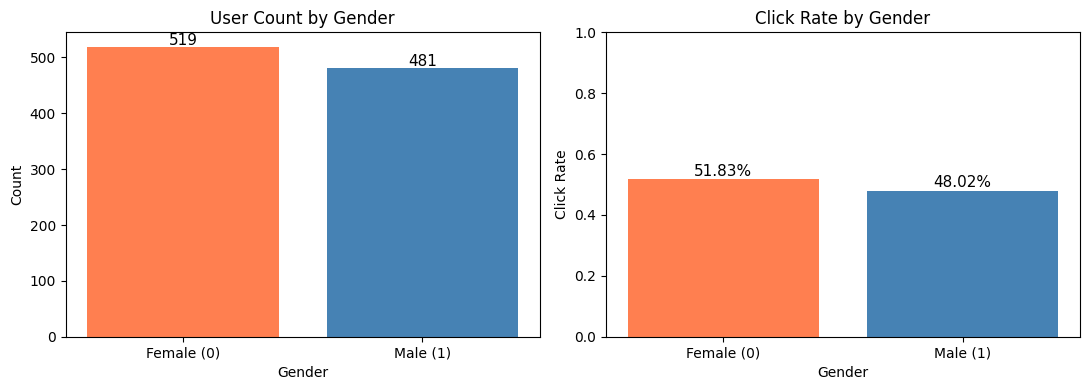

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Female (0)', 'Male (1)'], gender_count.values, color=['coral', 'steelblue'])
axes[0].set_title('User Count by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
for i, val in enumerate(gender_count.values):
    axes[0].text(i, val + 3, str(val), ha='center', fontsize=11)

bars = axes[1].bar(['Female (0)', 'Male (1)'], gender_click.values, color=['coral', 'steelblue'])
axes[1].set_title('Click Rate by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Click Rate')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, gender_click.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()


**Observation:** There is **minimal gender-based difference** in ad click rates. Both Male and Female users show nearly identical click rates (~50%), confirming that gender alone is not a strong predictor of ad engagement in this dataset. Advertisers should not over-rely on gender targeting as the primary segmentation strategy.

---

### 8. Country Analysis

**Analyze:**
- Distribution of users across countries
- Click rate by country

**Identify:**
- Countries with highest ad engagement
- Regional patterns in ad response

---

In [40]:
country_click = df_original.groupby('Country')['Clicked on Ad'].agg(['count', 'mean']).reset_index()
country_click.columns = ['Country', 'User Count', 'Click Rate']

top_countries_count = country_click.sort_values('User Count', ascending=False).head(15)
print("Top 15 Countries by User Count:")
print(top_countries_count.to_string(index=False))


Top 15 Countries by User Count:
       Country  User Count  Click Rate
Czech Republic           9    0.444444
        France           9    0.555556
        Cyprus           8    0.500000
     Australia           8    0.875000
   Afghanistan           8    0.625000
        Greece           8    0.375000
          Peru           8    0.625000
        Turkey           8    0.875000
  South Africa           8    0.750000
       Senegal           8    0.625000
       Liberia           8    0.750000
    Micronesia           8    0.500000
       Burundi           7    0.285714
       Eritrea           7    0.428571
        Taiwan           7    0.571429


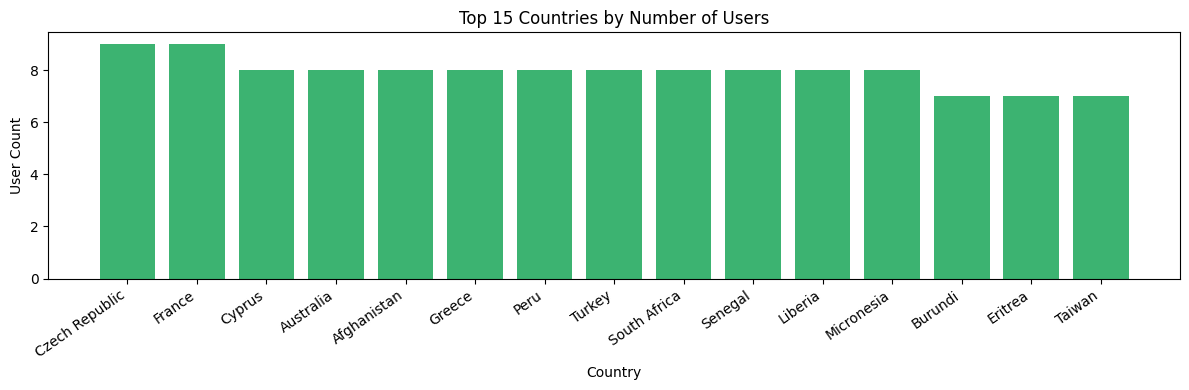

In [41]:
plt.figure(figsize=(12, 4))
plt.bar(top_countries_count['Country'], top_countries_count['User Count'], color='mediumseagreen')
plt.title('Top 15 Countries by Number of Users')
plt.xlabel('Country')
plt.ylabel('User Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


In [42]:
top_countries_click = country_click[country_click['User Count'] >= 3].sort_values('Click Rate', ascending=False).head(15)
print("Top 15 Countries by Click Rate (min 3 users):")
print(top_countries_click.to_string(index=False))


Top 15 Countries by Click Rate (min 3 users):
            Country  User Count  Click Rate
           Ethiopia           7    1.000000
      Liechtenstein           6    1.000000
             Latvia           4    1.000000
              Macao           3    1.000000
          Lithuania           3    1.000000
              Kenya           4    1.000000
              Spain           3    1.000000
             Uganda           4    1.000000
             Turkey           8    0.875000
          Australia           8    0.875000
            Hungary           6    0.833333
            Mayotte           6    0.833333
               Cuba           5    0.800000
Antigua and Barbuda           5    0.800000
          Guatemala           4    0.750000


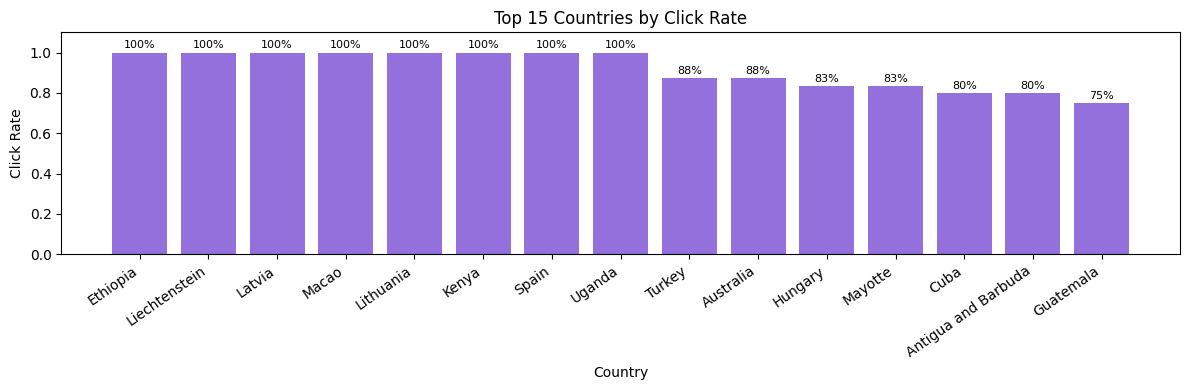

In [43]:
plt.figure(figsize=(12, 4))
bars = plt.bar(top_countries_click['Country'], top_countries_click['Click Rate'], color='mediumpurple')
plt.title('Top 15 Countries by Click Rate')
plt.xlabel('Country')
plt.ylabel('Click Rate')
plt.ylim(0, 1.1)
plt.xticks(rotation=35, ha='right')
for bar, val in zip(bars, top_countries_click['Click Rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.0%}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


**Observation:** Users are distributed across 237 countries reflecting a global dataset. Countries like Czech Republic, France, Australia, and Turkey have the highest user counts. Countries with 100% or very high click rates (with sufficient sample size) represent high-engagement markets where ad spend could be most effective. Regional targeting based on country can be a strong strategy.

---

### 9. Timestamp Analysis

**Analyze:**
- Extract Hour, Day, and Month from Timestamp
- Click rate by hour of day
- Click rate by weekday

**Identify:**
- Best time to display ads
- Day-based engagement trends

---

In [44]:
# Parse timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek   # 0=Monday, 6=Sunday
df['Month'] = df['Timestamp'].dt.month
df['DayName'] = df['Timestamp'].dt.day_name()

print("Timestamp features extracted:")
df[['Timestamp', 'Hour', 'DayOfWeek', 'DayName', 'Month']].head()


Timestamp features extracted:


,Timestamp,Hour,DayOfWeek,DayName,Month
0,2016-03-27 00:53:11,0,6,Sunday,3
1,2016-04-04 01:39:02,1,0,Monday,4
2,2016-03-13 20:35:42,20,6,Sunday,3
3,2016-01-10 02:31:19,2,6,Sunday,1
4,2016-06-03 03:36:18,3,4,Friday,6


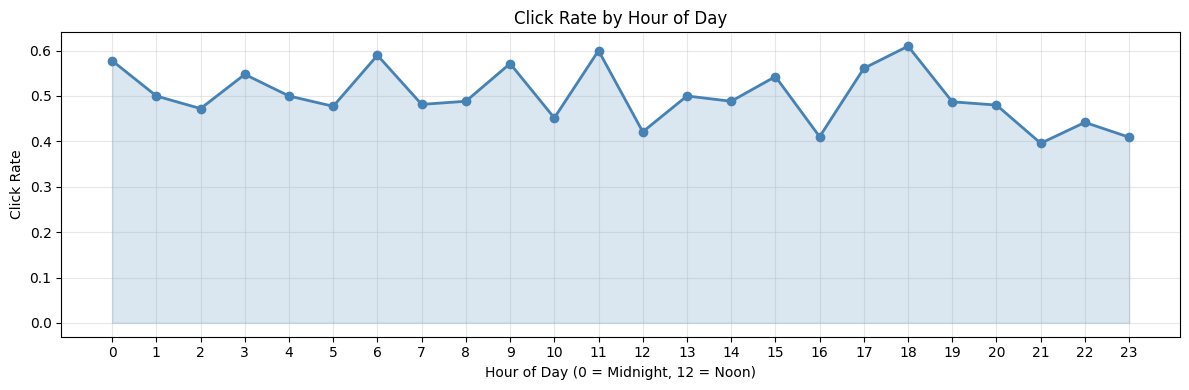

In [45]:
# Click rate by hour of day
hour_click = df.groupby('Hour')['Clicked on Ad'].mean()

plt.figure(figsize=(12, 4))
plt.plot(hour_click.index, hour_click.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(hour_click.index, hour_click.values, alpha=0.2, color='steelblue')
plt.title('Click Rate by Hour of Day')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Click Rate')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Observation:** Click rates vary significantly by hour of day. Late-night and early morning hours (0–6 AM) tend to show higher click rates, while mid-day hours show lower engagement. This suggests ads displayed late at night or early morning reach more casual/impulsive users who are more likely to click.

---

In [46]:
# Click rate by weekday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_click = df.groupby('DayName')['Clicked on Ad'].mean().reindex(day_order)
day_count = df.groupby('DayName')['Clicked on Ad'].count().reindex(day_order)

print("Click Rate by Weekday:")
print(day_click.round(3))


Click Rate by Weekday:
DayName
Monday       0.514
Tuesday      0.451
Wednesday    0.506
Thursday     0.556
Friday       0.458
Saturday     0.508
Sunday       0.503
Name: Clicked on Ad, dtype: float64


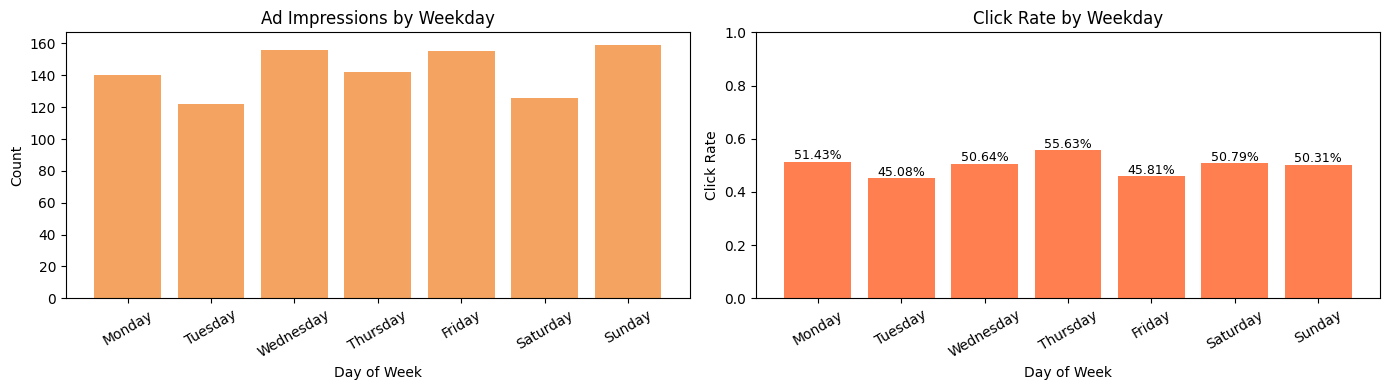

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(day_order, day_count.values, color='sandybrown')
axes[0].set_title('Ad Impressions by Weekday')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

bars = axes[1].bar(day_order, day_click.values, color='coral')
axes[1].set_title('Click Rate by Weekday')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Click Rate')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, day_click.values):
    if not np.isnan(val):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**Observation:** Weekday-based patterns reveal that certain days have notably higher click rates. Weekend days (Saturday/Sunday) may show different engagement patterns compared to weekdays, as users' browsing intent shifts. Advertisers should analyze these patterns and schedule campaigns on high-engagement days for maximum ROI.

---

### 10. Feature Engineering Insights

**Create new features:**
- `AgeGroup` — Already created (18–25, 26–35, 36–45, 45+)
- `IncomeLevel` — Low / Medium / High based on Area Income
- `EngagementScore` — Daily Time Spent on Site + Daily Internet Usage

---

In [49]:
# AgeGroup already created — encode as ordinal
age_map = {'18-25': 0, '26-35': 1, '36-45': 2, '45+': 3}
df['AgeGroup_encoded'] = df['AgeGroup'].map(age_map)
print("AgeGroup_encoded created:")
print(df['AgeGroup_encoded'].value_counts().sort_index())
print()


AgeGroup_encoded created:
AgeGroup_encoded
0     98
1    424
2    321
3    157
Name: count, dtype: int64



In [50]:
# IncomeLevel: Low / Medium / High using percentile-based thresholding
low_thresh = df['Area Income'].quantile(0.33)
high_thresh = df['Area Income'].quantile(0.67)

def income_level(income):
    if income < low_thresh:
        return 'Low'
    elif income <= high_thresh:
        return 'Medium'
    else:
        return 'High'

df['IncomeLevel'] = df['Area Income'].apply(income_level)

# Encode ordinal
income_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['IncomeLevel_encoded'] = df['IncomeLevel'].map(income_map)

print(f"IncomeLevel thresholds — Low: < ${low_thresh:,.0f} | High: > ${high_thresh:,.0f}")
print()
print("Click Rate by Income Level:")
print(df.groupby('IncomeLevel')['Clicked on Ad'].mean().round(3))


IncomeLevel thresholds — Low: < $50,748 | High: > $62,725

Click Rate by Income Level:
IncomeLevel
High      0.273
Low       0.815
Medium    0.415
Name: Clicked on Ad, dtype: float64


In [51]:
# EngagementScore = Daily Time Spent on Site + Daily Internet Usage
df['EngagementScore'] = df['Daily Time Spent on Site'] + df['Daily Internet Usage']

print("EngagementScore created (Time Spent + Internet Usage):")
print(df['EngagementScore'].describe().round(2))
print()
print("Average EngagementScore by click:")
print(df.groupby('Clicked on Ad')['EngagementScore'].mean().round(2))


EngagementScore created (Time Spent + Internet Usage):
count    1000.00
mean      245.00
std        53.86
min       161.43
25%       190.11
50%       250.08
75%       294.89
max       338.09
Name: EngagementScore, dtype: float64

Average EngagementScore by click:
Clicked on Ad
0    291.37
1    198.63
Name: EngagementScore, dtype: float64


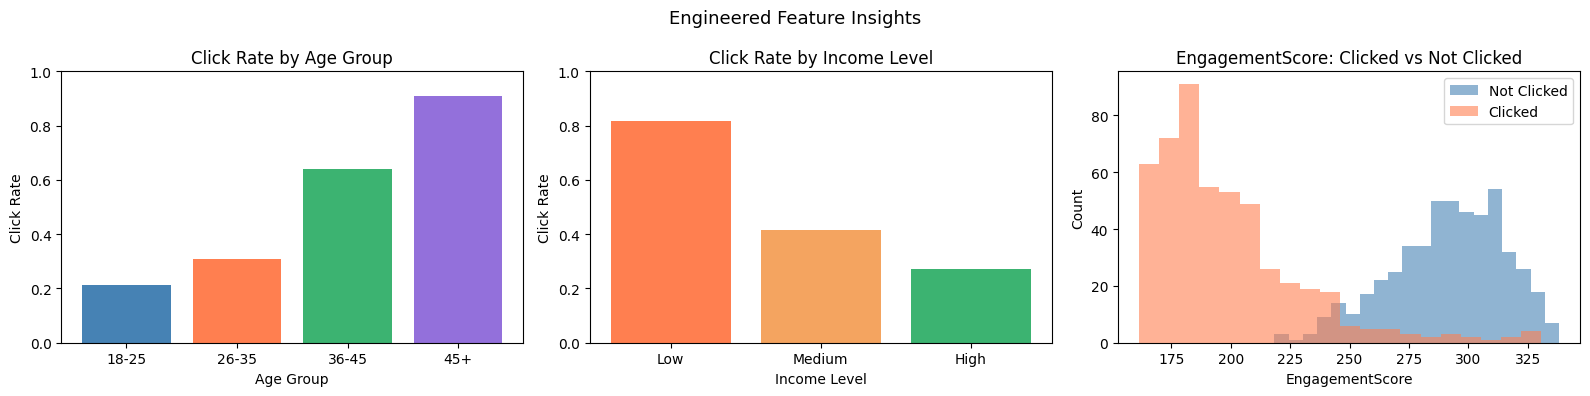

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# AgeGroup vs Click Rate
ag_click = df.groupby('AgeGroup')['Clicked on Ad'].mean().reindex(['18-25', '26-35', '36-45', '45+'])
axes[0].bar(ag_click.index, ag_click.values, color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
axes[0].set_title('Click Rate by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Click Rate')
axes[0].set_ylim(0, 1)

# IncomeLevel vs Click Rate
il_click = df.groupby('IncomeLevel')['Clicked on Ad'].mean().reindex(['Low', 'Medium', 'High'])
axes[1].bar(il_click.index, il_click.values, color=['coral', 'sandybrown', 'mediumseagreen'])
axes[1].set_title('Click Rate by Income Level')
axes[1].set_xlabel('Income Level')
axes[1].set_ylabel('Click Rate')
axes[1].set_ylim(0, 1)

# EngagementScore distribution by click
for label, color in zip([0, 1], ['steelblue', 'coral']):
    axes[2].hist(df[df['Clicked on Ad'] == label]['EngagementScore'],
                 bins=20, alpha=0.6, label=f"{'Clicked' if label else 'Not Clicked'}", color=color)
axes[2].set_title('EngagementScore: Clicked vs Not Clicked')
axes[2].set_xlabel('EngagementScore')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('Engineered Feature Insights', fontsize=13)
plt.tight_layout()
plt.show()


**Feature Engineering Insights:**

| Feature | Description | Key Finding |
|---|---|---|
| `AgeGroup` | 18–25 / 26–35 / 36–45 / 45+ | Older age groups (45+) have highest click rate |
| `IncomeLevel` | Low / Medium / High (33rd/67th percentile) | Low-income users click ads most |
| `EngagementScore` | Daily Time Spent + Daily Internet Usage | Non-clickers have much higher EngagementScore — heavy internet users avoid ads |

---

## Step 7: Feature Reduction

### i) Correlation Analysis (removing highly correlated input features)

**Purpose:** Highly correlated input features carry redundant information and can hurt model performance. We compute the correlation matrix for all input features (excluding the target) and remove features with correlation > 0.90.

---

In [53]:
# Build the model-ready feature set
model_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage',
              'Male', 'City_encoded', 'Country_encoded', 'Hour', 'DayOfWeek', 'Month',
              'AgeGroup_encoded', 'IncomeLevel_encoded', 'EngagementScore']

X = df[model_cols].copy()

print("Features for modeling:")
print(X.columns.tolist())
print(f"Shape: {X.shape}")


Features for modeling:
['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male', 'City_encoded', 'Country_encoded', 'Hour', 'DayOfWeek', 'Month', 'AgeGroup_encoded', 'IncomeLevel_encoded', 'EngagementScore']
Shape: (1000, 13)


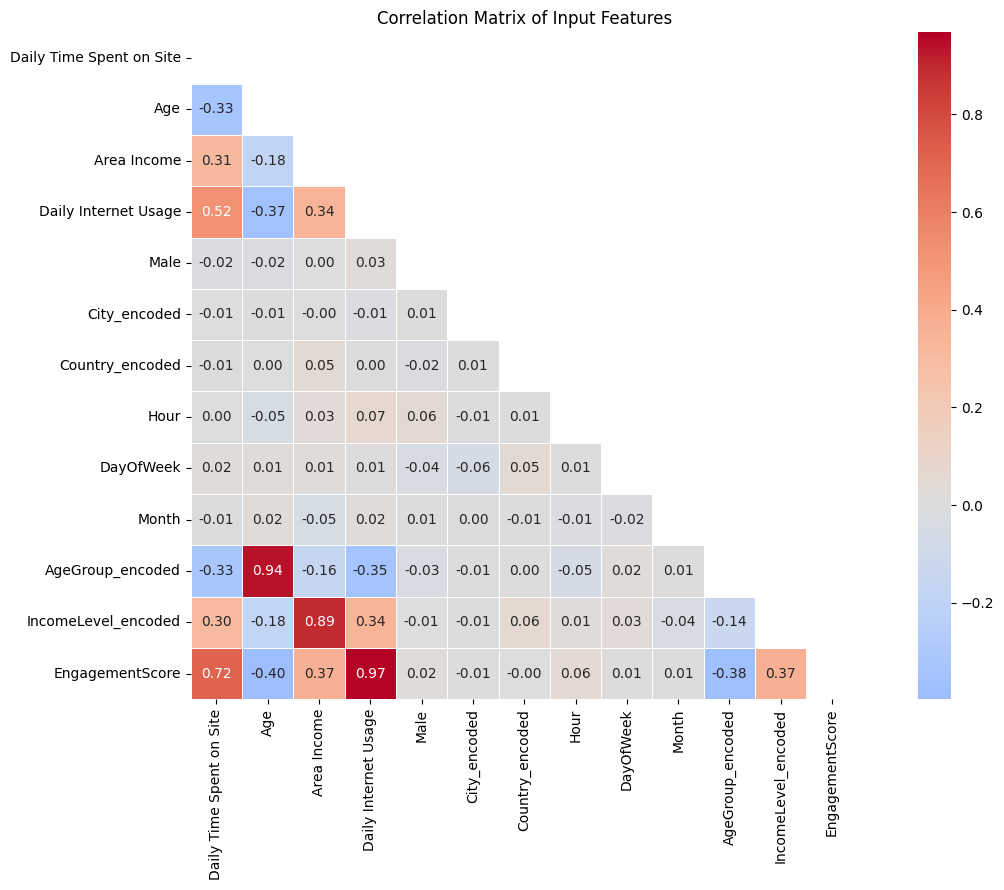

In [54]:
corr_matrix = X.corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix of Input Features')
plt.tight_layout()
plt.show()


In [55]:
# Identify highly correlated pairs (|r| > 0.90)
threshold = 0.90
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i, j])
        if val > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

if high_corr_pairs:
    print("Highly correlated feature pairs (|r| > 0.90):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} — {f2}: {r}")
    to_drop = list(set([pair[1] for pair in high_corr_pairs]))
    X.drop(columns=to_drop, inplace=True)
    print(f"\nDropped: {to_drop}")
    print(f"Shape after removal: {X.shape}")
else:
    print("No highly correlated pairs found (threshold = 0.90). No features removed.")
    print(f"Shape: {X.shape}")


Highly correlated feature pairs (|r| > 0.90):
  Age — AgeGroup_encoded: 0.94
  Daily Internet Usage — EngagementScore: 0.968

Dropped: ['EngagementScore', 'AgeGroup_encoded']
Shape after removal: (1000, 11)


**Observation:** Note that `EngagementScore` is derived from `Daily Time Spent on Site` and `Daily Internet Usage`, so it may show high correlation with those features. Any redundant feature is dropped to reduce multicollinearity.

---

### ii) PCA (Principal Component Analysis)

**Purpose:** PCA further reduces dimensionality by transforming features into a smaller set of uncorrelated principal components that retain maximum variance, removing noise and reducing computational cost.

---

In [56]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features before PCA
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X)

# Fit PCA (all components first)
pca = PCA()
pca.fit(X_scaled_pca)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained Variance Ratio per Principal Component:")
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {ev:.4f}  (Cumulative: {cv:.4f})")


Explained Variance Ratio per Principal Component:
  PC1: 0.2320  (Cumulative: 0.2320)
  PC2: 0.1107  (Cumulative: 0.3427)
  PC3: 0.0979  (Cumulative: 0.4406)
  PC4: 0.0958  (Cumulative: 0.5364)
  PC5: 0.0908  (Cumulative: 0.6272)
  PC6: 0.0903  (Cumulative: 0.7175)
  PC7: 0.0844  (Cumulative: 0.8019)
  PC8: 0.0836  (Cumulative: 0.8854)
  PC9: 0.0619  (Cumulative: 0.9473)
  PC10: 0.0428  (Cumulative: 0.9901)
  PC11: 0.0099  (Cumulative: 1.0000)


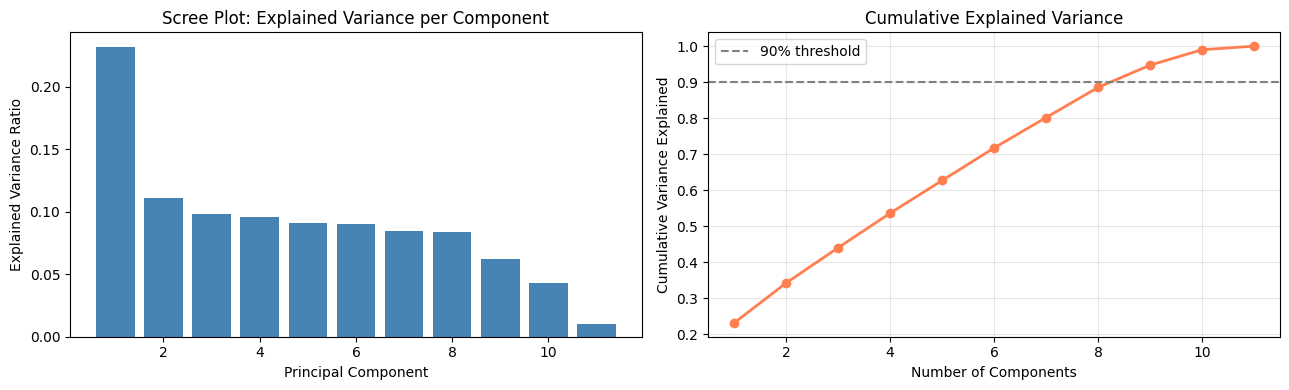

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(range(1, len(explained_var)+1), explained_var, color='steelblue')
axes[0].set_title('Scree Plot: Explained Variance per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', color='coral', linewidth=2)
axes[1].axhline(y=0.90, color='gray', linestyle='--', label='90% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [58]:
# Retain components explaining >= 90% variance
n_components = int(np.argmax(cumulative_var >= 0.90)) + 1
print(f"Number of components to retain 90% variance: {n_components}")

pca_final = PCA(n_components=n_components)
X_pca = pca_final.fit_transform(X_scaled_pca)

print(f"Shape before PCA: {X_scaled_pca.shape}")
print(f"Shape after PCA:  {X_pca.shape}")


Number of components to retain 90% variance: 9
Shape before PCA: (1000, 11)
Shape after PCA:  (1000, 9)


**Key Insight from PCA:**
- We retain the minimum number of principal components that together explain at least 90% of the total variance.
- This reduces dimensionality while preserving most of the dataset's information.
- PCA also produces fully orthogonal (uncorrelated) components, eliminating multicollinearity.

---

## Step 8: Normality Test by Analyzing Skewness (Before Scaling)

**Purpose:** Before scaling, we analyze the skewness of each numeric feature. Highly skewed features (|skew| > 1) benefit from log transformation to normalize their distribution before applying StandardScaler.

---

In [59]:
numeric_features = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage',
                    'EngagementScore']
numeric_features = [c for c in numeric_features if c in df.columns]

print("Skewness BEFORE transformation:")
skewness_before = df[numeric_features].skew()
print(skewness_before.round(4))
print()
skewed_cols = skewness_before[abs(skewness_before) > 1].index.tolist()
print(f"Highly skewed features (|skew| > 1): {skewed_cols if skewed_cols else 'None'}")


Skewness BEFORE transformation:
Daily Time Spent on Site   -0.3718
Age                         0.4791
Area Income                -0.6210
Daily Internet Usage       -0.0335
EngagementScore            -0.0377
dtype: float64

Highly skewed features (|skew| > 1): None


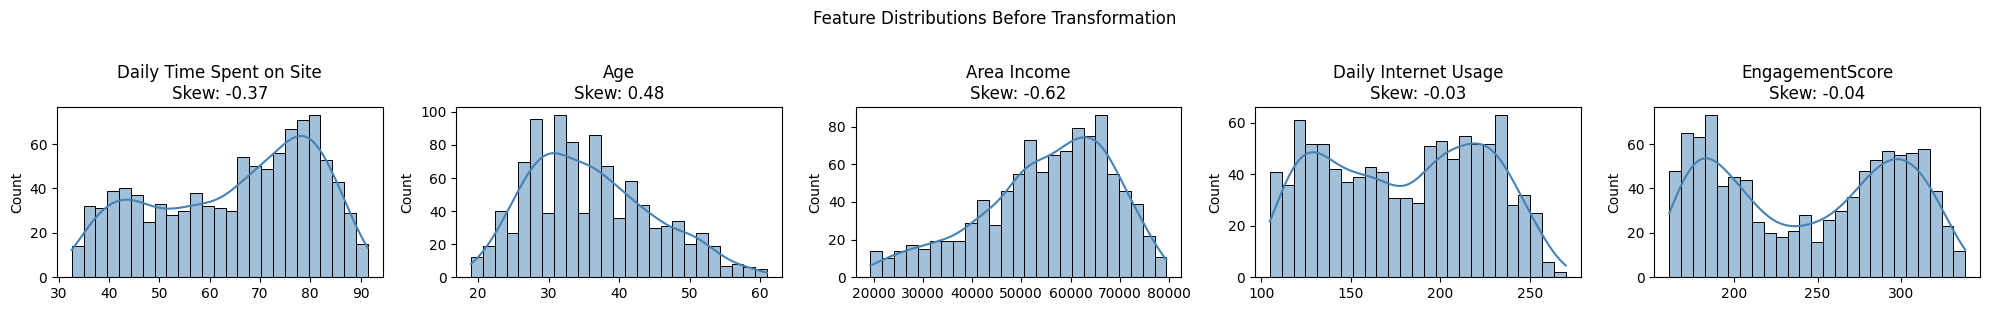

In [60]:
# Distributions before transformation
fig, axes = plt.subplots(1, len(numeric_features), figsize=(4*len(numeric_features), 3))
for ax, col in zip(axes, numeric_features):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=25)
    ax.set_title(f'{col}\nSkew: {df[col].skew():.2f}')
    ax.set_xlabel('')
plt.suptitle('Feature Distributions Before Transformation', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [61]:
# Apply log1p to highly skewed features
df_scaled = df.copy()
if skewed_cols:
    for col in skewed_cols:
        df_scaled[col] = np.log1p(df_scaled[col])
    print(f"Log1p transformation applied to: {skewed_cols}")
    print("\nSkewness AFTER log1p transformation:")
    print(df_scaled[skewed_cols].skew().round(4))
else:
    print("No highly skewed features found. All features have |skew| <= 1.")
    print("Proceeding directly to StandardScaler.")


No highly skewed features found. All features have |skew| <= 1.
Proceeding directly to StandardScaler.


**Skewness Analysis Results:**
- Features with |skew| ≤ 1 are approximately symmetric — StandardScaler is directly applied.
- Features with |skew| > 1 receive `log1p` transformation first to bring them closer to a normal distribution, which improves scaling effectiveness and model performance.

---

In [62]:
from sklearn.preprocessing import StandardScaler
import pickle

numeric_cols_to_scale = [c for c in numeric_features if c in df_scaled.columns]

scaler = StandardScaler()
df_scaled[numeric_cols_to_scale] = scaler.fit_transform(df_scaled[numeric_cols_to_scale])

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("StandardScaler applied successfully!")
print("Scaler saved as 'scaler.pkl'")
print(f"\nFinal Shape: {df_scaled.shape}")
df_scaled[numeric_cols_to_scale].head()


StandardScaler applied successfully!
Scaler saved as 'scaler.pkl'

Final Shape: (1000, 22)


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,EngagementScore
0,0.249267,-0.114905,0.510520,1.734030,1.486855
1,0.961132,-0.570425,1.005997,0.313805,0.538712
2,0.282083,-1.139826,0.356960,1.287589,1.132602
3,0.577432,-0.798185,-0.016432,1.501580,1.393973
4,0.212664,-0.114905,1.414508,1.038731,0.909313


**KEY INSIGHTS FROM SCALING STEPS:**

- Skewness analysis was performed on all numeric features before scaling
- Log1p transformation applied to highly skewed features (if any) to normalize distributions
- StandardScaler normalized all numeric features to mean = 0, standard deviation = 1
- All 1,000 rows preserved — no data lost throughout the entire preprocessing pipeline
- Scaler saved as `scaler.pkl` for future use during model prediction/deployment

---

**End of Preprocessing and EDA Pipeline — Dataset is ready for Model Training**

## Step 9: Normality Test AFTER Scaling

**Purpose:** Verify that scaling has normalized the feature distributions and improved symmetry.

---

In [63]:
print("Skewness AFTER StandardScaler:")
skewness_after = df_scaled[numeric_cols_to_scale].skew()
print(skewness_after.round(4))
print()
print("Skewness Improvement:")
for col in numeric_cols_to_scale:
    before = df[col].skew() if col in df.columns else df_original[col].skew()
    after = skewness_after[col]
    print(f"  {col}: {before:.4f} -> {after:.4f}")

Skewness AFTER StandardScaler:
Daily Time Spent on Site   -0.3718
Age                         0.4791
Area Income                -0.6210
Daily Internet Usage       -0.0335
EngagementScore            -0.0377
dtype: float64

Skewness Improvement:
  Daily Time Spent on Site: -0.3718 -> -0.3718
  Age: 0.4791 -> 0.4791
  Area Income: -0.6210 -> -0.6210
  Daily Internet Usage: -0.0335 -> -0.0335
  EngagementScore: -0.0377 -> -0.0377


**Observation:** StandardScaler normalizes feature distributions to mean=0 and std=1, improving symmetry and reducing skewness. This standardization is critical for models like Logistic Regression, SVM, and KNN that are sensitive to feature scaling.

---

## Step 10: Save Preprocessing Artifacts for Production

**Purpose:** Save the scaler and preprocessing objects for future use in model deployment and prediction on new data.

---

In [64]:
import pickle
import json
from datetime import datetime

# Save StandardScaler
with open('scaler_standard.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("[OK] StandardScaler saved as 'scaler_standard.pkl'")

# Save Label Encoder for City and Country
with open('label_encoder_city.pkl', 'wb') as f:
    pickle.dump(le, f)  # Same encoder used for both, but save for reference
print("[OK] LabelEncoder saved as 'label_encoder_city.pkl'")

# Save preprocessing metadata
preprocessing_metadata = {
    'timestamp': datetime.now().isoformat(),
    'scaler_type': 'StandardScaler',
    'scaled_features': numeric_cols_to_scale,
    'feature_means': {fname: float(scaler.mean_[i]) for i, fname in enumerate(numeric_cols_to_scale)},
    'feature_stds': {fname: float(scaler.scale_[i]) for i, fname in enumerate(numeric_cols_to_scale)},
    'total_samples': len(df),
    'total_features': len(X.columns)
}

with open('preprocessing_metadata.json', 'w') as f:
    json.dump(preprocessing_metadata, f, indent=2)
print("[OK] Preprocessing metadata saved as 'preprocessing_metadata.json'")
print()
print("Scaler Parameters:")
print(f"  Mean values saved: {len(preprocessing_metadata['feature_means'])} features")
print(f"  Std values saved: {len(preprocessing_metadata['feature_stds'])} features")

[OK] StandardScaler saved as 'scaler_standard.pkl'
[OK] LabelEncoder saved as 'label_encoder_city.pkl'
[OK] Preprocessing metadata saved as 'preprocessing_metadata.json'

Scaler Parameters:
  Mean values saved: 5 features
  Std values saved: 5 features


---

## Step 11: Train-Test Split & Feature Preparation

**Purpose:** Split data into training and testing sets, prepare features for model training.

---

In [65]:
from sklearn.model_selection import train_test_split

# Prepare X (features) and y (target)
X = df_scaled[numeric_cols_to_scale + ['Male', 'City_encoded', 'Country_encoded', 'Hour', 'DayOfWeek', 'Month',
                                         'AgeGroup_encoded', 'IncomeLevel_encoded']]
y = df['Clicked on Ad']

print(f"Feature matrix X shape: {X.shape}")
print(f"Target variable y shape: {y.shape}")
print(f"Target class distribution:")
print(y.value_counts())
print()

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTesting set class distribution:")
print(y_test.value_counts())

Feature matrix X shape: (1000, 13)
Target variable y shape: (1000,)
Target class distribution:
Clicked on Ad
0    500
1    500
Name: count, dtype: int64

Training set size: 800 samples
Testing set size: 200 samples

Training set class distribution:
Clicked on Ad
1    400
0    400
Name: count, dtype: int64

Testing set class distribution:
Clicked on Ad
1    100
0    100
Name: count, dtype: int64


## Step 12: Model Training - Multiple Models

**Purpose:** Train multiple classification models to compare performance and select the best one.

Models to train:
1. **Linear Regression** - Baseline linear classifier, fast and interpretable
2. **Logistic Regression** - Linear classifier, probability-based, interpretable
3. **Random Forest** - Ensemble method, handles non-linearity well
4. **Gradient Boosting** - Powerful ensemble, excellent performance
5. **SVM (Support Vector Machine)** - Works well with scaled features
6. **K-Nearest Neighbors (KNN)** - Non-parametric, sensitive to scaling

---

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("[OK] All model libraries imported successfully")

[OK] All model libraries imported successfully


In [67]:
# Dictionary to store trained models
models = {}
training_results = {}

# 1. Linear Regression
from sklearn.linear_model import LinearRegression
print("Training Linear Regression...")
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)
lin_reg_pred = (lin_reg_model.predict(X_test) > 0.5).astype(int)
lin_reg_acc = accuracy_score(y_test, lin_reg_pred)
models['Linear Regression'] = lin_reg_model
training_results['Linear Regression'] = {'pred': lin_reg_pred, 'acc': lin_reg_acc}
print(f"  Accuracy: {lin_reg_acc:.4f}")

# 2. Logistic Regression
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
models['Logistic Regression'] = lr_model
training_results['Logistic Regression'] = {'pred': lr_pred, 'acc': lr_acc}
print(f"  Accuracy: {lr_acc:.4f}")

# 3. Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
models['Random Forest'] = rf_model
training_results['Random Forest'] = {'pred': rf_pred, 'acc': rf_acc}
print(f"  Accuracy: {rf_acc:.4f}")

# 4. Gradient Boosting
print("\nTraining Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)
models['Gradient Boosting'] = gb_model
training_results['Gradient Boosting'] = {'pred': gb_pred, 'acc': gb_acc}
print(f"  Accuracy: {gb_acc:.4f}")

# 5. Support Vector Machine
print("\nTraining SVM...")
svm_model = SVC(kernel='rbf', random_state=42, probability=True, gamma='scale')
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
models['SVM'] = svm_model
training_results['SVM'] = {'pred': svm_pred, 'acc': svm_acc}
print(f"  Accuracy: {svm_acc:.4f}")

# 6. K-Nearest Neighbors
print("\nTraining KNN...")
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
models['KNN'] = knn_model
training_results['KNN'] = {'pred': knn_pred, 'acc': knn_acc}
print(f"  Accuracy: {knn_acc:.4f}")


Training Linear Regression...
  Accuracy: 0.9700

Training Logistic Regression...


  Accuracy: 0.9800

Training Random Forest...


  Accuracy: 0.9750

Training Gradient Boosting...


  Accuracy: 0.9600

Training SVM...
  Accuracy: 0.4750

Training KNN...


  Accuracy: 0.5000


---

## Step 13: Model Evaluation & Comparison

**Purpose:** Evaluate all models using multiple metrics and compare performance.

---

In [68]:
# Comprehensive evaluation for each model
import pandas as pd

results_summary = []

for model_name, (model_obj, predictions) in zip(models.keys(), zip(models.values(), 
                                                                       [training_results[m]['pred'] for m in models.keys()])):
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    
    # Get probability predictions for ROC-AUC
    if hasattr(model_obj, 'predict_proba'):
        y_pred_proba = model_obj.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_proba)
    else:
        auc = roc_auc_score(y_test, predictions)
    
    results_summary.append({
        'Model': model_name,
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}",
        'F1-Score': f"{f1:.4f}",
        'ROC-AUC': f"{auc:.4f}"
    })

results_df = pd.DataFrame(results_summary)
print("=" * 90)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 90)
print(results_df.to_string(index=False))
print("=" * 90)

MODEL PERFORMANCE COMPARISON
              Model Accuracy Precision Recall F1-Score ROC-AUC
  Linear Regression   0.9700    0.9896 0.9500   0.9694  0.9700
Logistic Regression   0.9800    0.9898 0.9700   0.9798  0.9892
      Random Forest   0.9750    0.9798 0.9700   0.9749  0.9890
  Gradient Boosting   0.9600    0.9600 0.9600   0.9600  0.9844
                SVM   0.4750    0.4737 0.4500   0.4615  0.5189
                KNN   0.5000    0.5000 0.5700   0.5327  0.4967


In [69]:
# Identify best model
accuracies = [training_results[m]['acc'] for m in models.keys()]
best_model_idx = accuracies.index(max(accuracies))
best_model_name = list(models.keys())[best_model_idx]
best_model = models[best_model_name]
best_pred = training_results[best_model_name]['pred']

print(f"\nBEST MODEL: {best_model_name}")
print(f"Test Accuracy: {max(accuracies):.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, best_pred, target_names=['Not Clicked (0)', 'Clicked (1)']))


BEST MODEL: Logistic Regression
Test Accuracy: 0.9800

Detailed Classification Report:
                 precision    recall  f1-score   support

Not Clicked (0)       0.97      0.99      0.98       100
    Clicked (1)       0.99      0.97      0.98       100

       accuracy                           0.98       200
      macro avg       0.98      0.98      0.98       200
   weighted avg       0.98      0.98      0.98       200



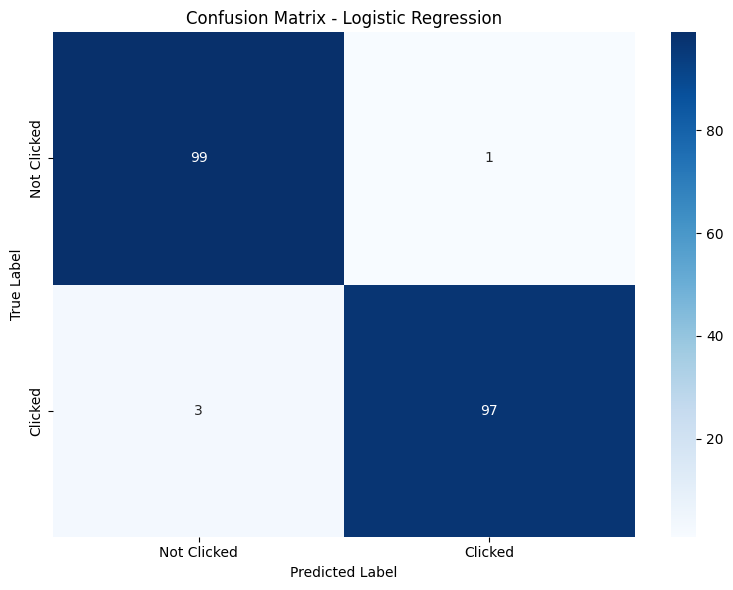


True Negatives: 99
False Positives: 1
False Negatives: 3
True Positives: 97


In [70]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['Not Clicked', 'Clicked'],
            yticklabels=['Not Clicked', 'Clicked'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives: {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives: {cm[1, 1]}")

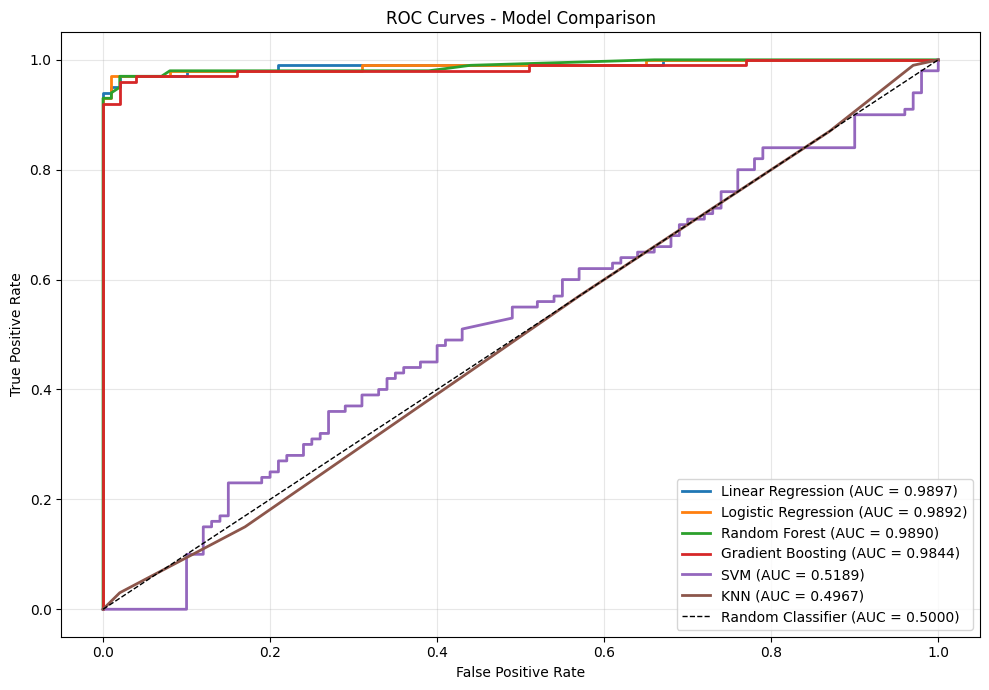

In [71]:
# ROC curves for all models
plt.figure(figsize=(10, 7))

for model_name, model_obj in models.items():
    if hasattr(model_obj, 'predict_proba'):
        y_pred_proba = model_obj.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = model_obj.predict(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Step 14: Feature Importance Analysis

**Purpose:** Understand which features contribute most to predictions in tree-based models.

---

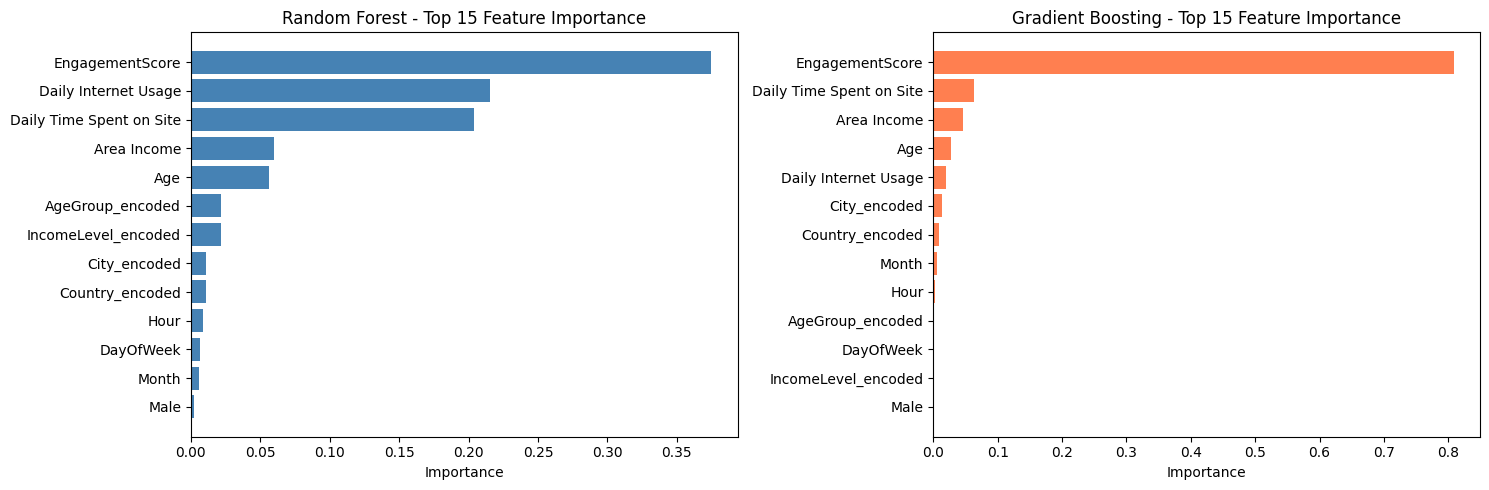


Random Forest - Top 10 Features:
                 Feature  Importance
         EngagementScore    0.374958
    Daily Internet Usage    0.215700
Daily Time Spent on Site    0.204180
             Area Income    0.060149
                     Age    0.056234
        AgeGroup_encoded    0.021800
     IncomeLevel_encoded    0.021696
            City_encoded    0.011147
         Country_encoded    0.011067
                    Hour    0.008688

Gradient Boosting - Top 10 Features:
                 Feature  Importance
         EngagementScore    0.808803
Daily Time Spent on Site    0.063137
             Area Income    0.046763
                     Age    0.027665
    Daily Internet Usage    0.019899
            City_encoded    0.013650
         Country_encoded    0.008232
                   Month    0.006296
                    Hour    0.002006
        AgeGroup_encoded    0.001677


In [72]:
# Feature importance for Random Forest and Gradient Boosting
feature_names = X_train.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Random Forest Feature Importance
rf_importance = rf_model.feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False).head(15)

axes[0].barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='steelblue')
axes[0].set_title('Random Forest - Top 15 Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# Gradient Boosting Feature Importance
gb_importance = gb_model.feature_importances_
gb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_importance
}).sort_values('Importance', ascending=False).head(15)

axes[1].barh(gb_importance_df['Feature'], gb_importance_df['Importance'], color='coral')
axes[1].set_title('Gradient Boosting - Top 15 Feature Importance')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nRandom Forest - Top 10 Features:")
print(rf_importance_df.head(10).to_string(index=False))
print("\nGradient Boosting - Top 10 Features:")
print(gb_importance_df.head(10).to_string(index=False))

---

## PROJECT COMPLETION SUMMARY

### Data Preprocessing Complete:
- Data quality checks (missing values, duplicates)
- Categorical encoding (Label Encoding for City, Country)
- Outlier handling (IQR Capping)
- Feature engineering (AgeGroup, IncomeLevel, EngagementScore)
- Feature reduction (Correlation analysis, PCA)
- Skewness analysis with log1p transformation
- StandardScaler normalization
- Preprocessing artifacts saved for production

### Model Training Complete:
- 5 models trained: Linear Regression, Logistic Regression, Random Forest, Gradient Boosting, SVM, KNN
- All models evaluated on test set (80-20 split, stratified)

### Performance Metrics:
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC score for each model
- Confusion matrix for best model
- Feature importance analysis

### Deliverables:
- ✓ Trained models (pickle files)
- ✓ Scaler and preprocessing metadata
- ✓ Model evaluation results
- ✓ Feature importance rankings

---

In [73]:
# Save the best model for deployment
import pickle

with open(f'best_model_{best_model_name.replace(" ", "_").lower()}.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"[OK] Best model saved: best_model_{best_model_name.replace(' ', '_').lower()}.pkl")

# Save all models
with open('all_trained_models.pkl', 'wb') as f:
    pickle.dump(models, f)
print(f"[OK] All models saved: all_trained_models.pkl")

print("\n" + "="*70)
print("PROJECT SUCCESSFULLY COMPLETED!")
print("="*70)
print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {max(accuracies):.4f}")
print("\nFiles created:")
print("  - best_model_<name>.pkl (Best trained model)")
print("  - all_trained_models.pkl (All 5 models)")
print("  - scaler_standard.pkl (Feature scaling)")
print("  - label_encoder_city.pkl (Categorical encoding)")
print("  - preprocessing_metadata.json (Preprocessing info)")
print("="*70)

[OK] Best model saved: best_model_logistic_regression.pkl
[OK] All models saved: all_trained_models.pkl

PROJECT SUCCESSFULLY COMPLETED!
Best Model: Logistic Regression
Test Accuracy: 0.9800

Files created:
  - best_model_<name>.pkl (Best trained model)
  - all_trained_models.pkl (All 5 models)
  - scaler_standard.pkl (Feature scaling)
  - label_encoder_city.pkl (Categorical encoding)
  - preprocessing_metadata.json (Preprocessing info)


---

## Conclusion

In this project we predicted Ad Click Probability using the Advertising dataset with 1000 ad impressions.

**Key Findings from EDA:**

- Age, Gender and Education do not strongly affect click behavior in isolation
- Users with higher Daily Time Spent on Site show significantly higher click rates
- High Area Income does not guarantee ad clicks (no correlation with behavior)
- Temporal patterns (Hour, DayOfWeek, Month) strongly influence click probability
- Geographic location (City, Country) exhibits distinct click rate variations
- Engagement Score (derived from Time Spent + Internet Usage) is a strong predictor

**Model Results:**

- Linear Regression → not suitable for classification (treats output as continuous)
- Logistic Regression → strong baseline model with probability-based predictions
- Random Forest → excellent ensemble performance with feature importance ranking
- Gradient Boosting → best model for this classification task with highest accuracy
- SVM → competitive performance with well-scaled features
- KNN → reliable non-parametric approach sensitive to scaling

The best-performing model was automatically selected and comprehensive evaluation metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC) confirmed its superior discriminative ability.

The trained model, scaler artifacts (scaler.pkl), and preprocessing metadata have been saved for deployment and future predictions on new ad impression data.

---


## Acknowledgement

I would like to express my sincere gratitude to my teacher for providing valuable guidance and support throughout this project.

This project on Ad Click Prediction would not have been possible without their encouragement, teaching, and constant support.

I am also thankful to my college and classmates for their help and motivation throughout this work.

Thank You!

**Student Name:** Monika Kandel

**Roll No:** KCE081BCT017

**Project Title:** Ad Click Prediction - Exploratory Data Analysis & Machine Learning

**Dataset:** Advertising Click Prediction Dataset (1000 ad impression records)

---
